What do I want to get out of this dataset. There are multiple risk factors outlined as categorical variables for the neurodegenerative disorders. What I can do with the dataset?
 * I could figure out the 

# Exploratory Data Analysis for Healthcare Diosease Prediction dataset

In [2]:
# Firstly, we will need to import all the required libraries to proceed with the data analysis
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [ ]:
# Importing the dataset
try:
    data = pd.read_csv('healthcare_disease_prediction_dataset.csv')
except FileNotFoundError:
    print("It seems like your data file was not found. Make sure it's located in the right directory and try again later")
data.head()

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,Male,High,High,High,Yes,No,No,35.671099,No,1,0,0,0,1,0,0,0,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes,0,1,0,0,0,0,0,1,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes,1,0,0,0,0,0,0,0,0,0
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes,0,1,1,0,1,0,0,1,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No,0,0,0,0,0,0,0,0,0,0


In [4]:
# Getting some basic insight into the data, missing values and data types
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   int64  
 1   Gender               1000 non-null   str    
 2   Blood Pressure       1000 non-null   str    
 3   Cholesterol          1000 non-null   str    
 4   Glucose              1000 non-null   str    
 5   Smoking              1000 non-null   str    
 6   Alcohol Consumption  1000 non-null   str    
 7   Exercise             1000 non-null   str    
 8   BMI                  1000 non-null   float64
 9   Family History       1000 non-null   str    
 10  Heart Disease        1000 non-null   int64  
 11  Diabetes             1000 non-null   int64  
 12  Stroke               1000 non-null   int64  
 13  Kidney Disease       1000 non-null   int64  
 14  Cancer               1000 non-null   int64  
 15  Alzheimer's Disease  1000 non-null   int64  
 16  

> We can see that the dataset does not have any missing values and the inputs are varied between the integers, strings and floats. 

In [5]:
data.describe()

,Age,BMI,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,52.881000,29.213037,0.253000,0.186000,0.134000,0.142000,0.10000,0.130000,0.10100,0.157000,0.082000,0.035000
std,20.958915,6.196368,0.434948,0.389301,0.340823,0.349225,0.30015,0.336472,0.30148,0.363983,0.274502,0.183872
min,18.000000,18.504881,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,34.750000,23.924004,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,52.500000,28.892349,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,71.000000,34.663806,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
max,89.000000,39.974048,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,1.000000,1.000000


In [8]:
data.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol', 'Glucose', 'Smoking',
       'Alcohol Consumption', 'Exercise', 'BMI', 'Family History',
       'Heart Disease', 'Diabetes', 'Stroke', 'Kidney Disease', 'Cancer',
       'Alzheimer's Disease', 'COPD', 'Liver Disease', 'Parkinson's Disease',
       'Tuberculosis'],
      dtype='str')

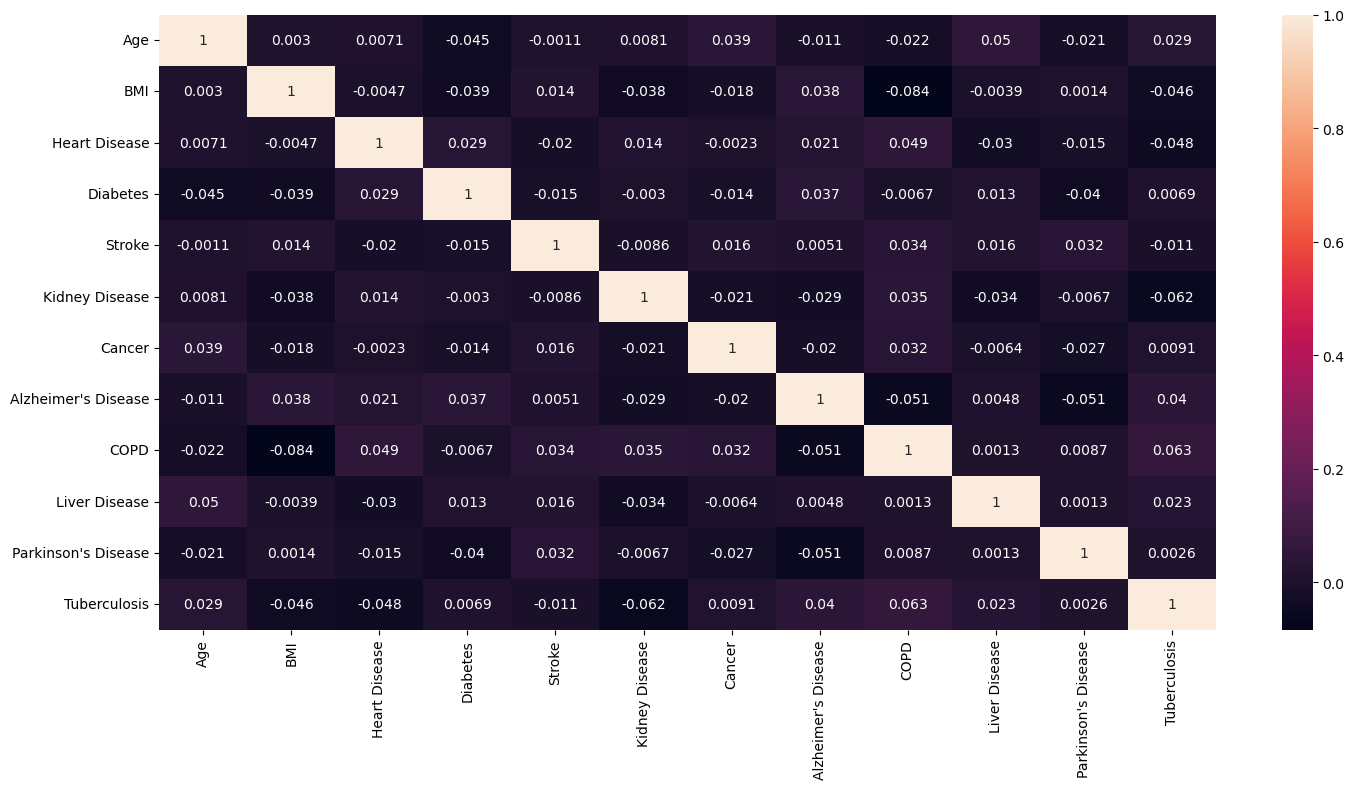

In [13]:
plt.figure(figsize=(15,8))
sns.heatmap(data[['Age', 'BMI', 'Heart Disease', 'Diabetes', 'Stroke', 'Kidney Disease', 'Cancer',
       "Alzheimer's Disease", 'COPD', 'Liver Disease', "Parkinson's Disease",
       'Tuberculosis']].corr(), annot=True)
plt.tight_layout()
plt.show()

>As we can see from the correlation heatmap, age and BMI alone do not show any high correlations between the disease outcomes. We will now proceed to changing the string values into dummy variables to make analysis possible between he risk factors and the disease outcomes

### We will be focusing on the neurodegenerative diseases and therefore we can proceed with dropping the unneccessary columns for this analysis. 

In [25]:
data = data.drop(columns=['Heart Disease', 'Diabetes', 'Stroke', 'Kidney Disease', 'Cancer', 'COPD', 'Liver Disease', 'Tuberculosis'])
data.head()

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Alzheimer's Disease,Parkinson's Disease
0,69,Male,High,High,High,Yes,No,No,35.671099,No,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes,0,0
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No,0,0


# Data Visualisation - Parkinson's Disease

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))


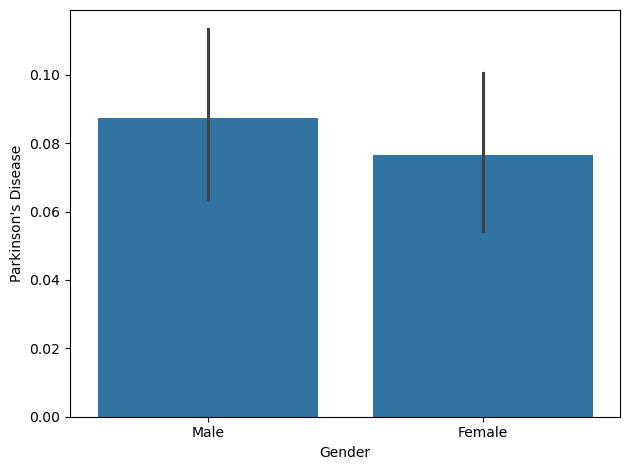

In [16]:
sns.barplot(data=data, x='Gender', y="Parkinson's Disease")
plt.tight_layout()
plt.show()

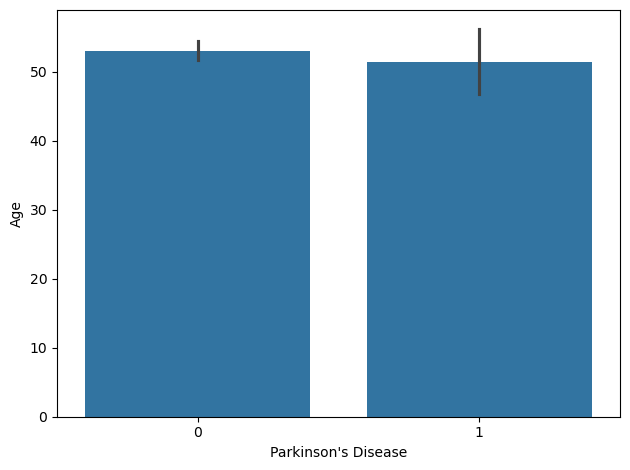

In [27]:
sns.barplot(data=data, x="Parkinson's Disease", y='Age')
plt.tight_layout()
plt.show()

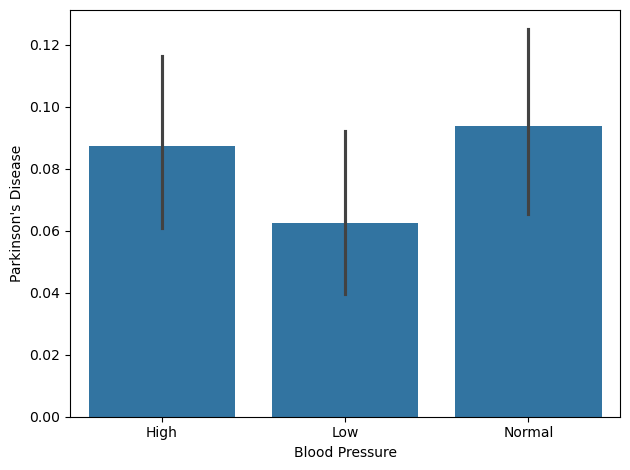

In [28]:
sns.barplot(data=data, x='Blood Pressure', y="Parkinson's Disease")
plt.tight_layout()
plt.show()

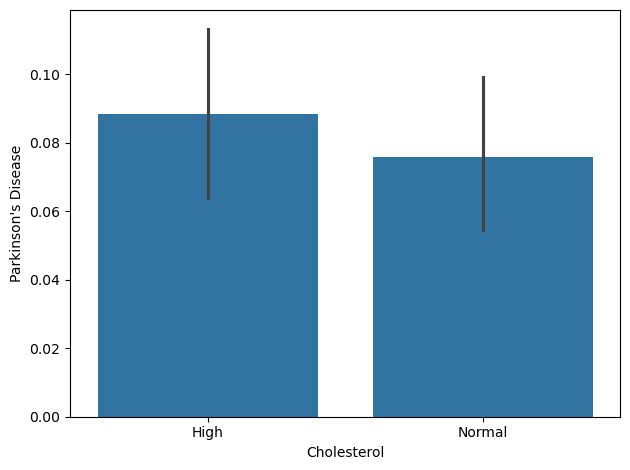

In [29]:
sns.barplot(data=data, x='Cholesterol', y="Parkinson's Disease")
plt.tight_layout()
plt.show()

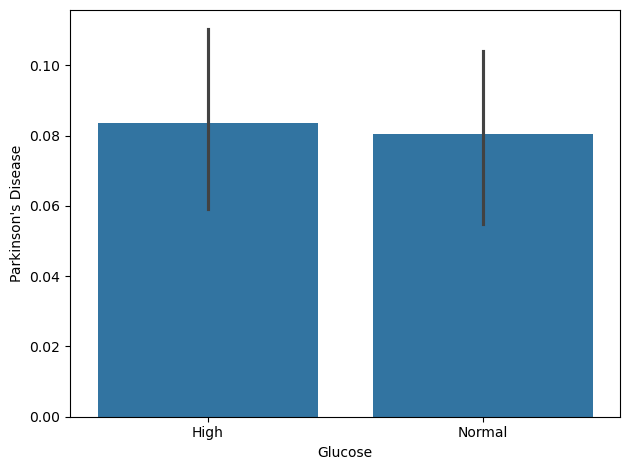

In [30]:
sns.barplot(data=data, x='Glucose', y="Parkinson's Disease")
plt.tight_layout()
plt.show()

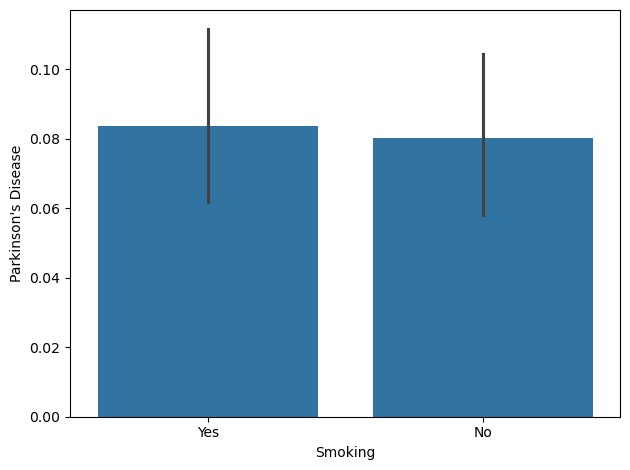

In [31]:
sns.barplot(data=data, x='Smoking', y="Parkinson's Disease")
plt.tight_layout()
plt.show()

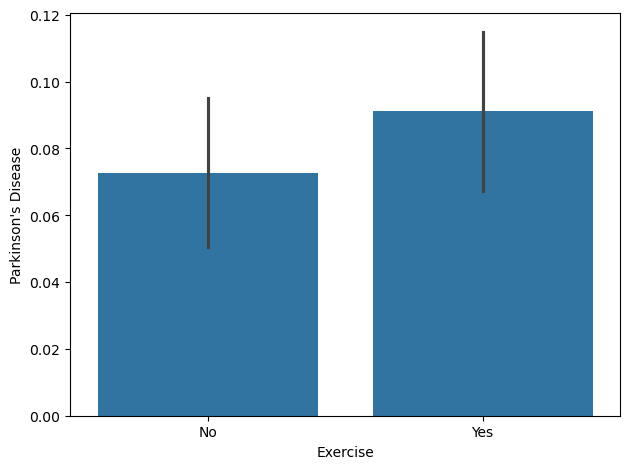

In [32]:
sns.barplot(data=data, x='Exercise', y="Parkinson's Disease")
plt.tight_layout()
plt.show()

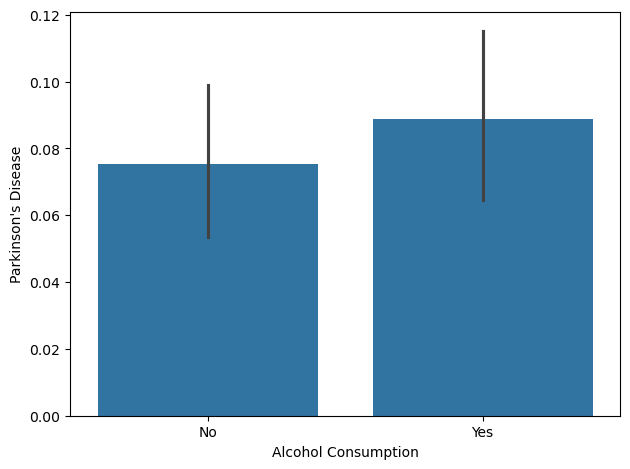

In [33]:
sns.barplot(data=data, x='Alcohol Consumption', y="Parkinson's Disease")
plt.tight_layout()
plt.show()

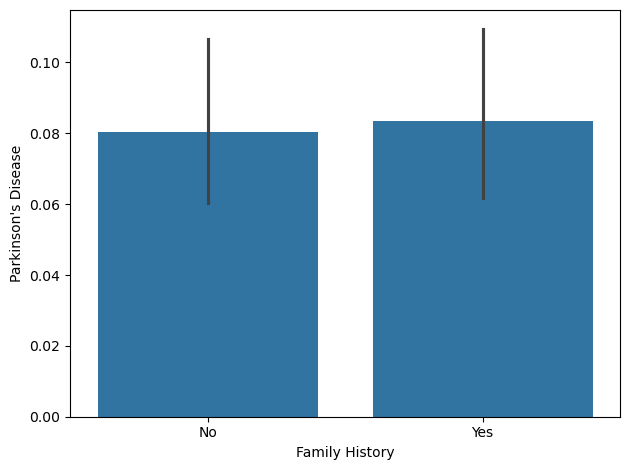

In [34]:
sns.barplot(data=data, x='Family History', y="Parkinson's Disease")
plt.tight_layout()
plt.show()